STEP 1: Loading Dataset
Dataset shape : (177866, 17)  (177,866 rows x 17 columns)

Columns:
['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range', 'Base MSRP', 'Legislative District', 'DOL Vehicle ID', 'Vehicle Location', 'Electric Utility', '2020 Census Tract']

First 3 rows:
   VIN (1-10)     County     City State  Postal Code  Model Year   Make  \
0  5YJYGDEE1L       King  Seattle    WA      98122.0        2020  TESLA   
1  7SAYGDEE9P  Snohomish  Bothell    WA      98021.0        2023  TESLA   
2  5YJSA1E4XK       King  Seattle    WA      98109.0        2019  TESLA   

     Model           Electric Vehicle Type  \
0  MODEL Y  Battery Electric Vehicle (BEV)   
1  MODEL Y  Battery Electric Vehicle (BEV)   
2  MODEL S  Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel

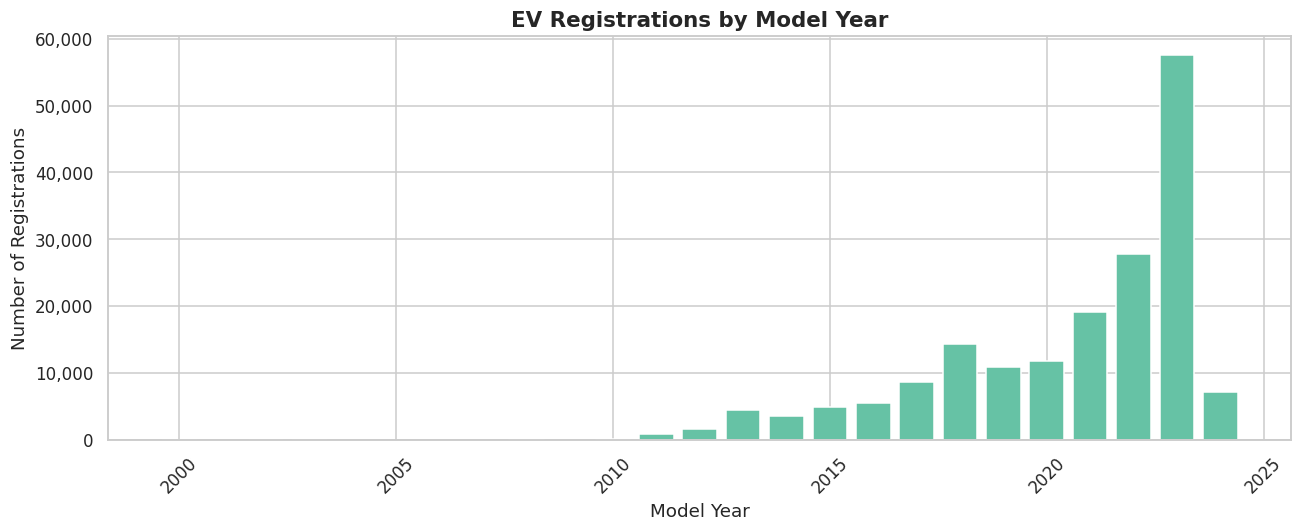


STEP 5: Geographical Distribution

Top 10 Counties:
County
King         92740
Snohomish    21001
Pierce       13782
Clark        10416
Thurston      6428
Kitsap        5840
Spokane       4586
Whatcom       4253
Benton        2147
Skagit        1910

Top 10 Cities:
City
Seattle      29447
Bellevue      8931
Redmond       6478
Vancouver     6193
Bothell       5863
Kirkland      5362
Sammamish     5280
Renton        4980
Olympia       4299
Tacoma        3722


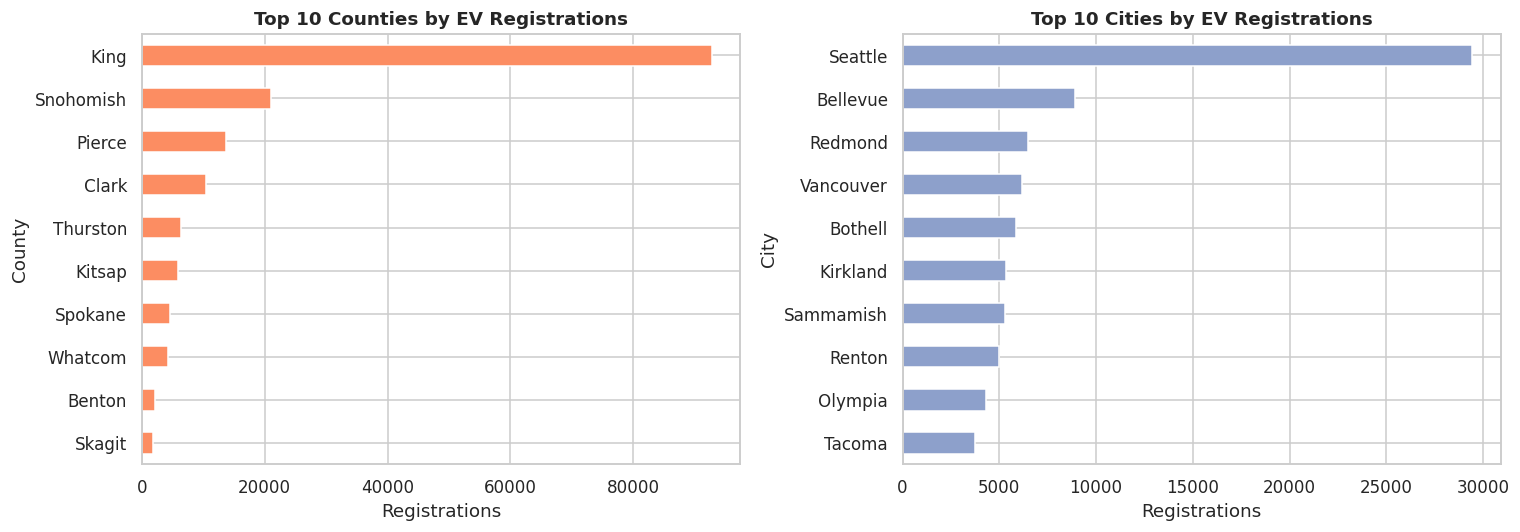


STEP 6: Make & Model Popularity

Top 10 Makes:
Make
TESLA         79655
NISSAN        13997
CHEVROLET     13678
FORD           9199
BMW            7570
KIA            7432
TOYOTA         6288
VOLKSWAGEN     5004
JEEP           4480
HYUNDAI        4406

Top 10 Models:
Model
MODEL Y           35989
MODEL 3           30091
LEAF              13365
MODEL S            7734
BOLT EV            6821
MODEL X            5795
VOLT               4796
ID.4               3937
WRANGLER           3392
MUSTANG MACH-E     3322


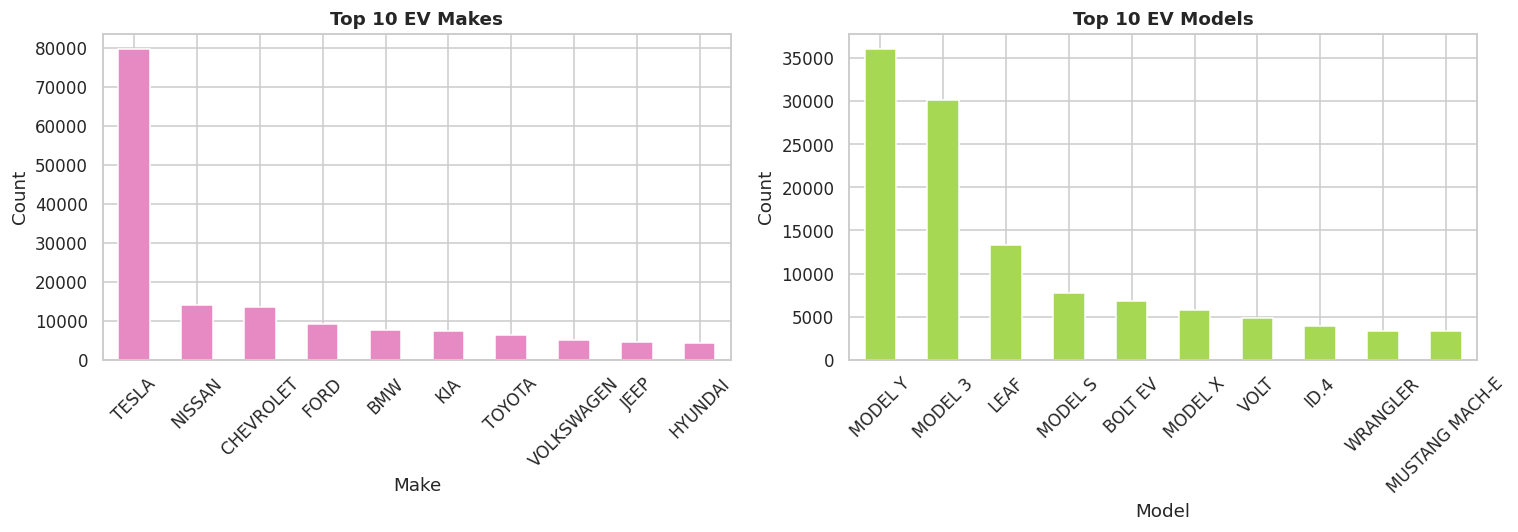


STEP 7: EV Type Distribution
Electric Vehicle Type
Battery Electric Vehicle (BEV)            139205
Plug-in Hybrid Electric Vehicle (PHEV)     38656


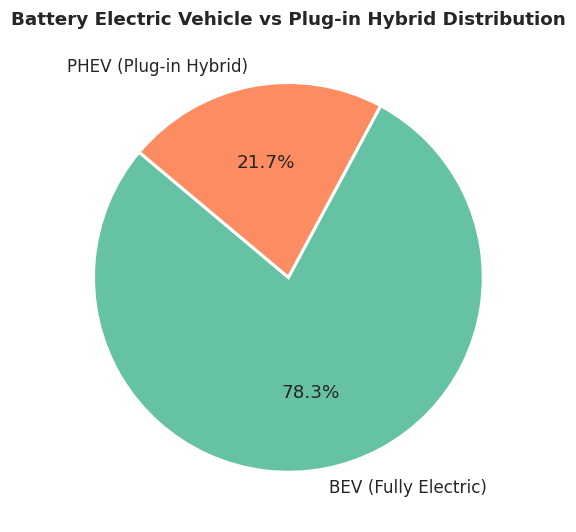


STEP 8: Electric Range Analysis
Valid range records : 85,911
Mean range          : 121.8 miles
Max range           : 337 miles


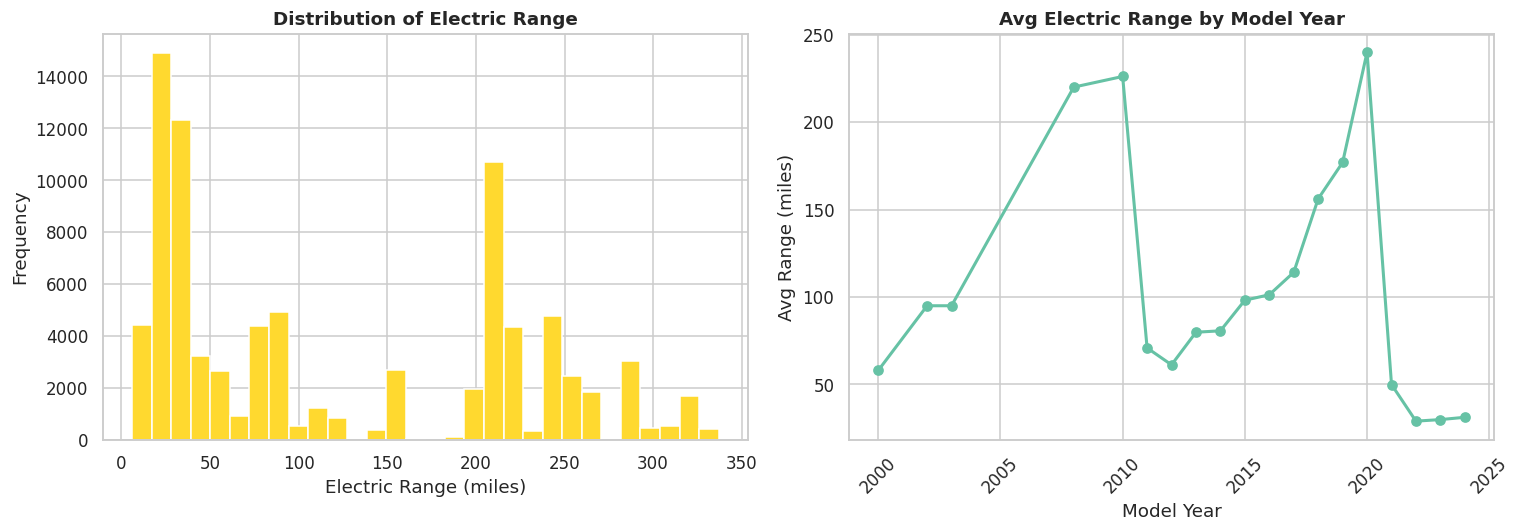


STEP 9: CAFV Eligibility Distribution
CAFV Short
Unknown         91950
Eligible        66326
Not Eligible    19585


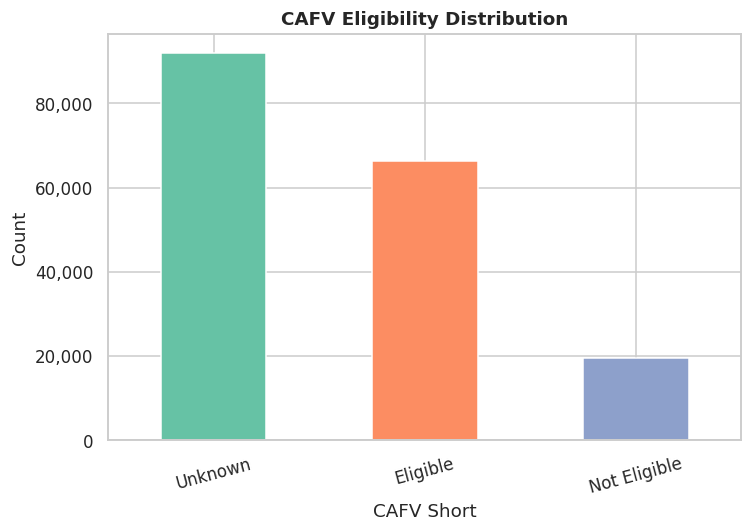


STEP 10: Correlation Analysis
Correlation Matrix:
                Electric Range  Base MSRP  Model Year
Electric Range           1.000      0.406      -0.933
Base MSRP                0.406      1.000      -0.463
Model Year              -0.933     -0.463       1.000

Pearson r (Range vs MSRP): 0.406  (p-value: 0.0000)


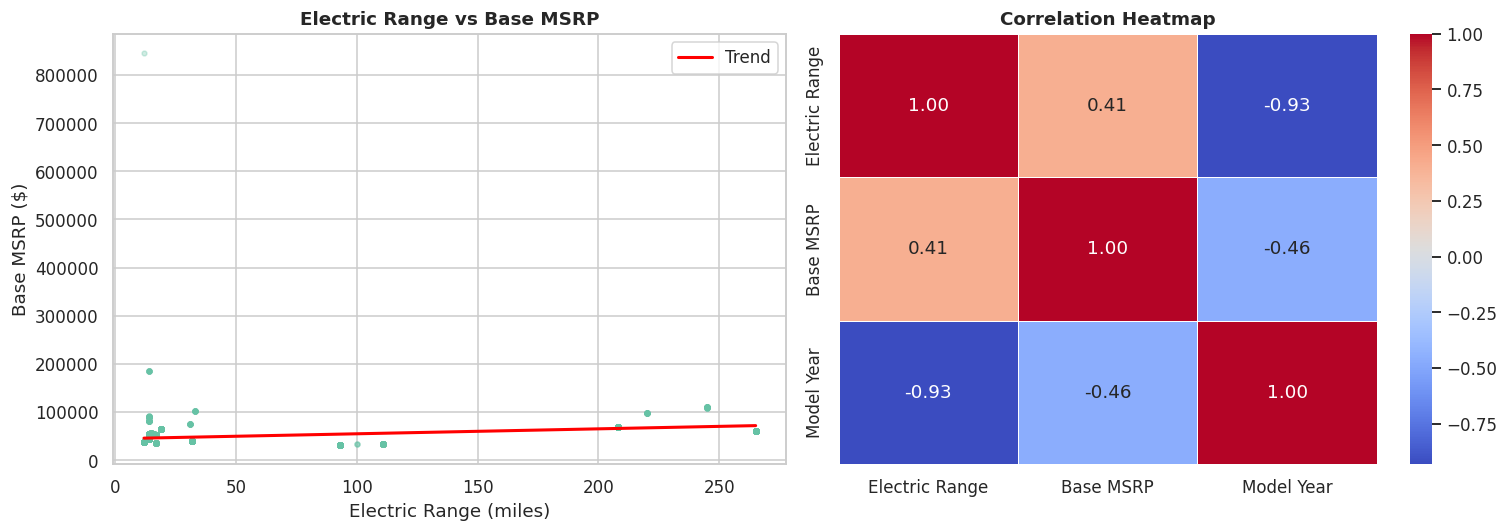


STEP 11: Market Size Estimation & Forecasting
Linear Regression:  slope=2234.9, intercept=-4495873.5
R² = 0.4629

Forecasted Registrations:
  2024: 27,499
  2025: 29,733
  2026: 31,968
  2027: 34,203


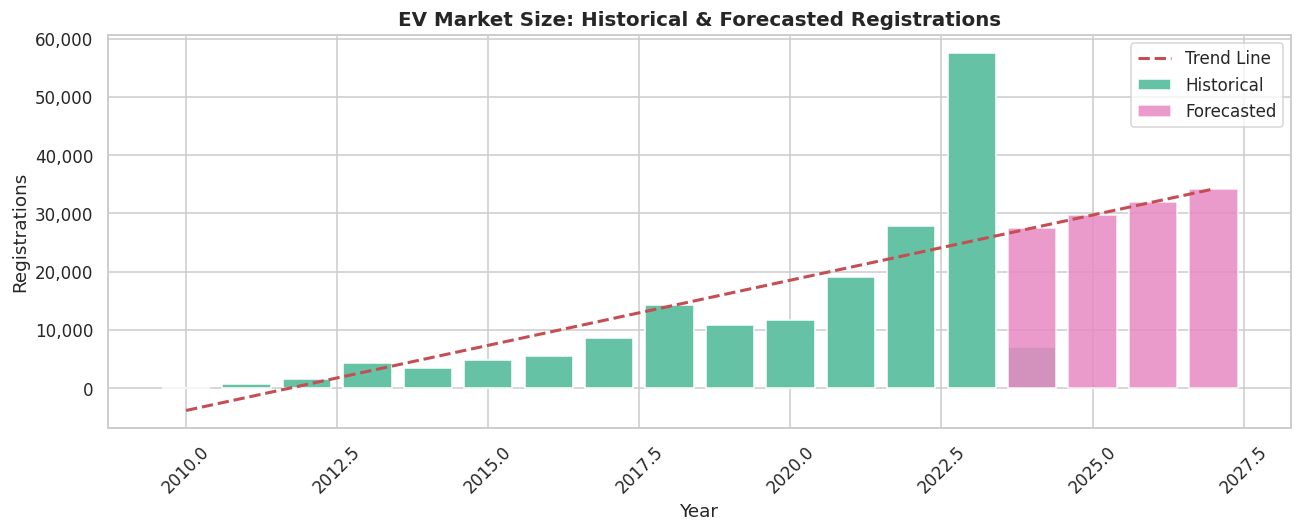


STEP 12: Summary Dashboard
  Total EV Records     : 177,861
  BEV Share            : 78.3%
  Top Manufacturer     : TESLA
  Top County           : King
  Avg Electric Range   : 121.8 miles
  Latest Model Year    : 2024

All analysis steps complete!


In [ ]:
"""
Market Size Analysis on Electric Vehicles Industries
Name   : Nimisha Sughal
Course : Data Science
Date   : May 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'figure.autolayout': True})
COLORS = sns.color_palette('Set2')

# ============================================================
# STEP 1 - Loading Dataset
# ============================================================
print('=' * 60)
print('STEP 1: Loading Dataset')
print('=' * 60)

df = pd.read_excel('/content/Electric_Vehicle_Population_Data_Excel_sheet.xlsx')

print(f'Dataset shape : {df.shape}  ({df.shape[0]:,} rows x {df.shape[1]} columns)')
print(f'\nColumns:\n{df.columns.tolist()}')
print(f'\nFirst 3 rows:')
print(df.head(3))


# ============================================================
# STEP 2 - Data Cleaning & Preparation
# ============================================================
print('\n' + '=' * 60)
print('STEP 2: Data Cleaning & Preparation')
print('=' * 60)

print('\nMissing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# dropping rows where location fields are missing
df.dropna(subset=['County', 'City', 'Postal Code'], inplace=True)

# 0 range or 0 price doesnt make sense — treating as missing data
df['Electric Range'] = df['Electric Range'].replace(0, np.nan)
df['Base MSRP'] = df['Base MSRP'].replace(0, np.nan)

df['Model Year'] = df['Model Year'].astype(int)

print(f'\nAfter cleaning - Dataset shape: {df.shape}')
print(f'Electric Range null count : {df["Electric Range"].isnull().sum():,}')
print(f'Base MSRP null count      : {df["Base MSRP"].isnull().sum():,}')


# ============================================================
# STEP 3 - Descriptive Statistics
# ============================================================
print('\n' + '=' * 60)
print('STEP 3: Descriptive Statistics')
print('=' * 60)

num_cols = ['Electric Range', 'Base MSRP', 'Model Year']
print(df[num_cols].describe().round(2))

for col in ['Electric Range', 'Base MSRP']:
    vals = df[col].dropna()
    print(f'\n{col}:')
    print(f'  Mean   : {vals.mean():,.2f}')
    print(f'  Median : {vals.median():,.2f}')
    print(f'  Std Dev: {vals.std():,.2f}')


# ============================================================
# STEP 4 - EV Registrations by Model Year
# ============================================================
print('\n' + '=' * 60)
print('STEP 4: EV Registrations by Model Year')
print('=' * 60)

ev_by_year = df.groupby('Model Year').size().reset_index(name='Registrations')
ev_by_year = ev_by_year[ev_by_year['Model Year'] >= 2000]

print(ev_by_year.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ev_by_year['Model Year'], ev_by_year['Registrations'],
       color=COLORS[0], edgecolor='white')
ax.set_title('EV Registrations by Model Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Model Year')
ax.set_ylabel('Number of Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# growth after 2020 is massive — 2023 numbers are more than double 2021


# ============================================================
# STEP 5 - Geographical Distribution
# ============================================================
print('\n' + '=' * 60)
print('STEP 5: Geographical Distribution')
print('=' * 60)

top_counties = df['County'].value_counts().head(10)
top_cities   = df['City'].value_counts().head(10)

print('\nTop 10 Counties:')
print(top_counties.to_string())
print('\nTop 10 Cities:')
print(top_cities.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_counties.plot(kind='barh', ax=axes[0], color=COLORS[1])
axes[0].set_title('Top 10 Counties by EV Registrations', fontweight='bold')
axes[0].set_xlabel('Registrations')
axes[0].invert_yaxis()

top_cities.plot(kind='barh', ax=axes[1], color=COLORS[2])
axes[1].set_title('Top 10 Cities by EV Registrations', fontweight='bold')
axes[1].set_xlabel('Registrations')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# King County and Seattle dominate — urban high income areas adopt EVs first


# ============================================================
# STEP 6 - Make & Model Popularity
# ============================================================
print('\n' + '=' * 60)
print('STEP 6: Make & Model Popularity')
print('=' * 60)

top_makes  = df['Make'].value_counts().head(10)
top_models = df['Model'].value_counts().head(10)

print('\nTop 10 Makes:')
print(top_makes.to_string())
print('\nTop 10 Models:')
print(top_models.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_makes.plot(kind='bar', ax=axes[0], color=COLORS[3], edgecolor='white')
axes[0].set_title('Top 10 EV Makes', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

top_models.plot(kind='bar', ax=axes[1], color=COLORS[4], edgecolor='white')
axes[1].set_title('Top 10 EV Models', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Tesla dominates by a huge margin — Model Y and Model 3 are top 2 by far


# ============================================================
# STEP 7 - EV Type Distribution
# ============================================================
print('\n' + '=' * 60)
print('STEP 7: EV Type Distribution')
print('=' * 60)

ev_type_counts = df['Electric Vehicle Type'].value_counts()
print(ev_type_counts.to_string())

labels = ['BEV (Fully Electric)', 'PHEV (Plug-in Hybrid)']

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(ev_type_counts,
       labels=labels,
       autopct='%1.1f%%',
       colors=[COLORS[0], COLORS[1]],
       startangle=140,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Battery Electric Vehicle vs Plug-in Hybrid Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

# 78% fully electric — people are committing to EVs not just going hybrid


# ============================================================
# STEP 8 - Electric Range Analysis
# ============================================================
print('\n' + '=' * 60)
print('STEP 8: Electric Range Analysis')
print('=' * 60)

range_valid = df['Electric Range'].dropna()
print(f'Valid range records : {len(range_valid):,}')
print(f'Mean range          : {range_valid.mean():.1f} miles')
print(f'Max range           : {range_valid.max():.0f} miles')

avg_range_year = (df.groupby('Model Year')['Electric Range']
                    .mean().dropna().reset_index())
avg_range_year = avg_range_year[avg_range_year['Model Year'] >= 2000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(range_valid, bins=30, color=COLORS[5], edgecolor='white')
axes[0].set_title('Distribution of Electric Range', fontweight='bold')
axes[0].set_xlabel('Electric Range (miles)')
axes[0].set_ylabel('Frequency')

axes[1].plot(avg_range_year['Model Year'], avg_range_year['Electric Range'],
             marker='o', color=COLORS[0], linewidth=2)
axes[1].set_title('Avg Electric Range by Model Year', fontweight='bold')
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Avg Range (miles)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# most cars cluster around 200-300 miles range


# ============================================================
# STEP 9 - CAFV Eligibility Distribution
# ============================================================
print('\n' + '=' * 60)
print('STEP 9: CAFV Eligibility Distribution')
print('=' * 60)

cafv_col = 'Clean Alternative Fuel Vehicle (CAFV) Eligibility'
cafv_map = {
    'Clean Alternative Fuel Vehicle Eligible'                        : 'Eligible',
    'Not eligible due to low battery range'                         : 'Not Eligible',
    'Eligibility unknown as battery range has not been researched'  : 'Unknown',
}
df['CAFV Short'] = df[cafv_col].map(cafv_map).fillna('Other')
cafv_counts = df['CAFV Short'].value_counts()
print(cafv_counts.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
cafv_counts.plot(kind='bar', ax=ax, color=COLORS[:3], edgecolor='white')
ax.set_title('CAFV Eligibility Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


# ============================================================
# STEP 10 - Correlation Analysis
# ============================================================
print('\n' + '=' * 60)
print('STEP 10: Correlation Analysis')
print('=' * 60)

corr_df = df[['Electric Range', 'Base MSRP', 'Model Year']].dropna()
corr_matrix = corr_df.corr().round(3)
print('Correlation Matrix:')
print(corr_matrix)

r, p = stats.pearsonr(corr_df['Electric Range'], corr_df['Base MSRP'])
print(f'\nPearson r (Range vs MSRP): {r:.3f}  (p-value: {p:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(corr_df['Electric Range'], corr_df['Base MSRP'],
                alpha=0.3, color=COLORS[0], s=10)
m, b = np.polyfit(corr_df['Electric Range'], corr_df['Base MSRP'], 1)
x_line = np.linspace(corr_df['Electric Range'].min(), corr_df['Electric Range'].max(), 200)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2, label='Trend')
axes[0].set_title('Electric Range vs Base MSRP', fontweight='bold')
axes[0].set_xlabel('Electric Range (miles)')
axes[0].set_ylabel('Base MSRP ($)')
axes[0].legend()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Heatmap', fontweight='bold')

plt.tight_layout()
plt.show()

# r = 0.41 means moderate positive correlation — higher range does cost more
# but its not super strong, other factors like brand and features matter too


# ============================================================
# STEP 11 - Market Size Estimation & Forecasting
# ============================================================
print('\n' + '=' * 60)
print('STEP 11: Market Size Estimation & Forecasting')
print('=' * 60)

# using 2010 onwards — earlier data is too sparse to be reliable
ev_trend = ev_by_year[ev_by_year['Model Year'] >= 2010].copy()
x = ev_trend['Model Year'].values
y = ev_trend['Registrations'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
print(f'Linear Regression:  slope={slope:.1f}, intercept={intercept:.1f}')
print(f'R² = {r_value**2:.4f}')

forecast_years = np.arange(2024, 2028)
forecast_vals  = np.maximum(slope * forecast_years + intercept, 0)

print('\nForecasted Registrations:')
for yr, val in zip(forecast_years, forecast_vals):
    print(f'  {yr}: {int(val):,}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(ev_trend['Model Year'], ev_trend['Registrations'],
       color=COLORS[0], label='Historical', edgecolor='white')
ax.bar(forecast_years, forecast_vals,
       color=COLORS[3], label='Forecasted', edgecolor='white', alpha=0.85)

x_fit = np.arange(ev_trend['Model Year'].min(), 2028)
ax.plot(x_fit, slope * x_fit + intercept, 'r--', linewidth=2, label='Trend Line')

ax.set_title('EV Market Size: Historical & Forecasted Registrations',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# linear model predicts steady growth — real growth could be faster
# with more government incentives and cheaper batteries coming in


# ============================================================
# STEP 12 - Summary Dashboard
# ============================================================
print('\n' + '=' * 60)
print('STEP 12: Summary Dashboard')
print('=' * 60)

total_evs  = len(df)
bev_pct    = (df['Electric Vehicle Type'].str.contains('BEV').sum() / total_evs) * 100
top_make   = df['Make'].value_counts().idxmax()
top_county = df['County'].value_counts().idxmax()
avg_range  = df['Electric Range'].mean()
latest_yr  = df['Model Year'].max()

print(f'  Total EV Records     : {total_evs:,}')
print(f'  BEV Share            : {bev_pct:.1f}%')
print(f'  Top Manufacturer     : {top_make}')
print(f'  Top County           : {top_county}')
print(f'  Avg Electric Range   : {avg_range:.1f} miles')
print(f'  Latest Model Year    : {latest_yr}')

print('\n' + '=' * 60)
print('All analysis steps complete!')
print('=' * 60)